In [1]:
# ============================================================
# FUNCTION 5 — WEEK 6 CLEAN REBUILD
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.spatial import cKDTree

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    Matern,
    WhiteKernel
)

# ------------------------------------------------------------
# 1. Load original Function 5 data
# ------------------------------------------------------------

X = np.load("function5/initial_inputs.npy")
Y = np.load("function5/initial_outputs.npy").reshape(-1)

# ------------------------------------------------------------
# 2. Add Weeks 1–5 exactly once
# ------------------------------------------------------------

weekly_X = np.array([
    [0.377511, 0.871594, 0.988652, 0.967795],  # Week 1
    [0.398348, 0.896184, 0.926939, 0.972836],  # Week 2
    [0.359181, 0.928233, 1.000000, 1.000000],  # Week 3
    [0.479181, 1.000000, 1.000000, 1.000000],  # Week 4
    [0.729149, 1.000000, 1.000000, 1.000000]   # Week 5
])

weekly_Y = np.array([
    2687.686511102482,
    2360.0402820167205,
    3650.138639563766,
    4641.863904371854,
    5518.777035831257
])

X = np.vstack([
    X,
    weekly_X
])

Y = np.concatenate([
    Y,
    weekly_Y
])

best_index = np.argmax(Y)
best_x = X[best_index]
best_y = Y[best_index]

print("Week 6 X shape:", X.shape)
print("Week 6 Y shape:", Y.shape)

print("\nBest observed input:")
print(best_x)

print("Best observed output:")
print(best_y)

print("\nWeek 5 point:")
print(weekly_X[-1])

print("Week 5 output:")
print(weekly_Y[-1])

Week 6 X shape: (25, 4)
Week 6 Y shape: (25,)

Best observed input:
[0.729149 1.       1.       1.      ]
Best observed output:
5518.777035831257

Week 5 point:
[0.729149 1.       1.       1.      ]
Week 5 output:
5518.777035831257


In [2]:
# ============================================================
# 3. SCALE OUTPUTS
# ============================================================

Y_mean = Y.mean()
Y_std = Y.std()

Y_scaled = (
    Y - Y_mean
) / Y_std

print("Output mean:", Y_mean)
print("Output standard deviation:", Y_std)

Output mean: 875.3577554586535
Output standard deviation: 1557.2834852146395


In [3]:
# ============================================================
# 4. FIT ARD GAUSSIAN PROCESS
# ============================================================

kernel = (
    C(
        1.0,
        (1e-3, 1e3)
    )
    *
    Matern(
        length_scale=[
            0.20,
            0.20,
            0.20,
            0.20
        ],
        length_scale_bounds=(
            0.005,
            3.0
        ),
        nu=2.5
    )
    +
    WhiteKernel(
        noise_level=1e-5,
        noise_level_bounds=(
            1e-10,
            1e-1
        )
    )
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=False,
    n_restarts_optimizer=20,
    random_state=65
)

gp.fit(
    X,
    Y_scaled
)

print("Fitted kernel:")
print(gp.kernel_)

lengthscales = np.asarray(
    gp.kernel_.k1.k2.length_scale
)

importance = 1 / lengthscales
importance = importance / importance.sum()

print("\nFitted lengthscales:")
print(lengthscales)

print("\nNormalised input influence:")

for i, value in enumerate(
    importance,
    start=1
):
    print(f"x{i}: {value:.4f}")

Fitted kernel:
2.02**2 * Matern(length_scale=[2.6, 0.778, 0.871, 3], nu=2.5) + WhiteKernel(noise_level=0.00581)

Fitted lengthscales:
[2.60203036 0.77765553 0.87083024 3.        ]

Normalised input influence:
x1: 0.1219
x2: 0.4080
x3: 0.3643
x4: 0.1058


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [4]:
# ============================================================
# 5. GENERATE WEEK 6 CANDIDATES
# ============================================================

rng = np.random.default_rng(65)

week5_point = np.array([
    0.729149,
    1.000000,
    1.000000,
    1.000000
])

week4_point = np.array([
    0.479181,
    1.000000,
    1.000000,
    1.000000
])

# ------------------------------------------------------------
# A. Main x1 boundary search
#
# x2, x3 and x4 remain exactly 1.
# ------------------------------------------------------------

boundary_x1 = rng.uniform(
    0.68,
    0.90,
    size=25_000
)

boundary_candidates = np.column_stack([
    boundary_x1,
    np.ones(25_000),
    np.ones(25_000),
    np.ones(25_000)
])

# ------------------------------------------------------------
# B. Very local around Week 5
# ------------------------------------------------------------

very_local = rng.normal(
    loc=week5_point,
    scale=[
        0.012,
        0.003,
        0.003,
        0.003
    ],
    size=(15_000, 4)
)

# ------------------------------------------------------------
# C. Local around Week 5
# ------------------------------------------------------------

local = rng.normal(
    loc=week5_point,
    scale=[
        0.035,
        0.008,
        0.008,
        0.008
    ],
    size=(15_000, 4)
)

# ------------------------------------------------------------
# D. Near-boundary search
#
# Allows us to test whether slightly below 1 is actually better.
# ------------------------------------------------------------

near_boundary = np.column_stack([
    rng.uniform(
        0.67,
        0.88,
        size=12_000
    ),
    rng.uniform(
        0.985,
        1.000,
        size=12_000
    ),
    rng.uniform(
        0.985,
        1.000,
        size=12_000
    ),
    rng.uniform(
        0.985,
        1.000,
        size=12_000
    )
])

# ------------------------------------------------------------
# E. Small extrapolation further along x1
#
# We do not know whether performance keeps increasing.
# ------------------------------------------------------------

higher_x1 = np.column_stack([
    rng.uniform(
        0.78,
        0.95,
        size=8_000
    ),
    np.ones(8_000),
    np.ones(8_000),
    np.ones(8_000)
])

candidates = np.vstack([
    boundary_candidates,
    very_local,
    local,
    near_boundary,
    higher_x1
])

candidates = np.clip(
    candidates,
    0,
    1
)

print(
    "Candidates before filtering:",
    len(candidates)
)

Candidates before filtering: 75000


In [5]:
# ============================================================
# 6. REMOVE NEAR-DUPLICATES
# ============================================================

tree = cKDTree(X)

minimum_distance, _ = tree.query(
    candidates,
    k=1
)

keep = (
    minimum_distance > 0.003
)

candidates = candidates[
    keep
]

print(
    "Candidates after filtering:",
    len(candidates)
)

Candidates after filtering: 72797


In [6]:
# ============================================================
# 7. GP PREDICTIONS
# ============================================================

mean_scaled, std_scaled = gp.predict(
    candidates,
    return_std=True
)

# Convert back to original Function 5 scale
mean = (
    mean_scaled * Y_std
    + Y_mean
)

std = (
    std_scaled * Y_std
)

In [7]:
# ============================================================
# 8. EXPECTED IMPROVEMENT + UCB
# ============================================================

xi = 10.0

improvement = (
    mean
    - best_y
    - xi
)

with np.errstate(
    divide="ignore",
    invalid="ignore"
):

    z = (
        improvement / std
    )

    ei = (
        improvement * norm.cdf(z)
        +
        std * norm.pdf(z)
    )

ei[std < 1e-12] = 0

# Low exploration weight
kappa = 0.30

ucb = (
    mean
    + kappa * std
)

In [8]:
# ============================================================
# 9. FILTER WEAK PREDICTIONS
# ============================================================

mean_filter = (
    mean >= best_y - 500
)

if np.sum(mean_filter) < 100:

    mean_filter = (
        mean >= np.percentile(
            mean,
            90
        )
    )

filtered_candidates = candidates[
    mean_filter
]

filtered_mean = mean[
    mean_filter
]

filtered_std = std[
    mean_filter
]

filtered_ei = ei[
    mean_filter
]

filtered_ucb = ucb[
    mean_filter
]

print(
    "Candidates passing mean filter:",
    len(filtered_candidates)
)

Candidates passing mean filter: 72551


In [9]:
# ============================================================
# 10. ACQUISITION SCORE
# ============================================================

ei_norm = (
    filtered_ei
    - filtered_ei.min()
) / (
    np.ptp(filtered_ei)
    + 1e-12
)

ucb_norm = (
    filtered_ucb
    - filtered_ucb.min()
) / (
    np.ptp(filtered_ucb)
    + 1e-12
)

# Very exploitation-heavy after strong Week 5 result
acquisition = (
    0.90 * ei_norm
    +
    0.10 * ucb_norm
)

chosen_index = np.argmax(
    acquisition
)

week6_query = filtered_candidates[
    chosen_index
]

In [10]:
# ============================================================
# 11. FUNCTION 5 — WEEK 6 PORTAL OUTPUT
# ============================================================

print("\nSuggested Week 6 query:")
print(week6_query)

print("\nPortal format:")
print(
    "-".join(
        f"{value:.6f}"
        for value in week6_query
    )
)

print(
    "\nPredicted mean:",
    filtered_mean[chosen_index]
)

print(
    "Predicted uncertainty:",
    filtered_std[chosen_index]
)

print(
    "Expected Improvement:",
    filtered_ei[chosen_index]
)

print(
    "UCB:",
    filtered_ucb[chosen_index]
)

print(
    "Distance from Week 5:",
    np.linalg.norm(
        week6_query
        - week5_point
    )
)

print(
    "x1 change from Week 5:",
    week6_query[0]
    - week5_point[0]
)


Suggested Week 6 query:
[0.94999547 1.         1.         1.        ]

Portal format:
0.949995-1.000000-1.000000-1.000000

Predicted mean: 5960.45792537357
Predicted uncertainty: 256.3281198352122
Expected Improvement: 436.55333095467915
UCB: 6037.356361324134
Distance from Week 5: 0.22084646798146945
x1 change from Week 5: 0.22084646798146945


In [11]:
# ============================================================
# 12. TOP 10 FUNCTION 5 WEEK 6 CANDIDATES
# ============================================================

top_indices = np.argsort(
    acquisition
)[-10:][::-1]

print("\nTOP 10 FUNCTION 5 WEEK 6 CANDIDATES")
print("-" * 100)

for rank, idx in enumerate(
    top_indices,
    start=1
):

    print(
        f"{rank:2d}. "
        f"point={filtered_candidates[idx]}  "
        f"mean={filtered_mean[idx]:.2f}  "
        f"std={filtered_std[idx]:.2f}  "
        f"EI={filtered_ei[idx]:.2f}  "
        f"acq={acquisition[idx]:.4f}"
    )


TOP 10 FUNCTION 5 WEEK 6 CANDIDATES
----------------------------------------------------------------------------------------------------
 1. point=[0.94999547 1.         1.         1.        ]  mean=5960.46  std=256.33  EI=436.55  acq=1.0000
 2. point=[0.94994645 1.         1.         1.        ]  mean=5960.35  std=256.30  EI=436.45  acq=0.9998
 3. point=[0.94989975 1.         1.         1.        ]  mean=5960.24  std=256.27  EI=436.34  acq=0.9995
 4. point=[0.94984713 1.         1.         1.        ]  mean=5960.13  std=256.24  EI=436.23  acq=0.9993
 5. point=[0.94977213 1.         1.         1.        ]  mean=5959.96  std=256.19  EI=436.06  acq=0.9989
 6. point=[0.94976921 1.         1.         1.        ]  mean=5959.95  std=256.19  EI=436.06  acq=0.9989
 7. point=[0.9497547 1.        1.        1.       ]  mean=5959.92  std=256.18  EI=436.03  acq=0.9989
 8. point=[0.94974703 1.         1.         1.        ]  mean=5959.90  std=256.18  EI=436.01  acq=0.9988
 9. point=[0.94970976 1.  

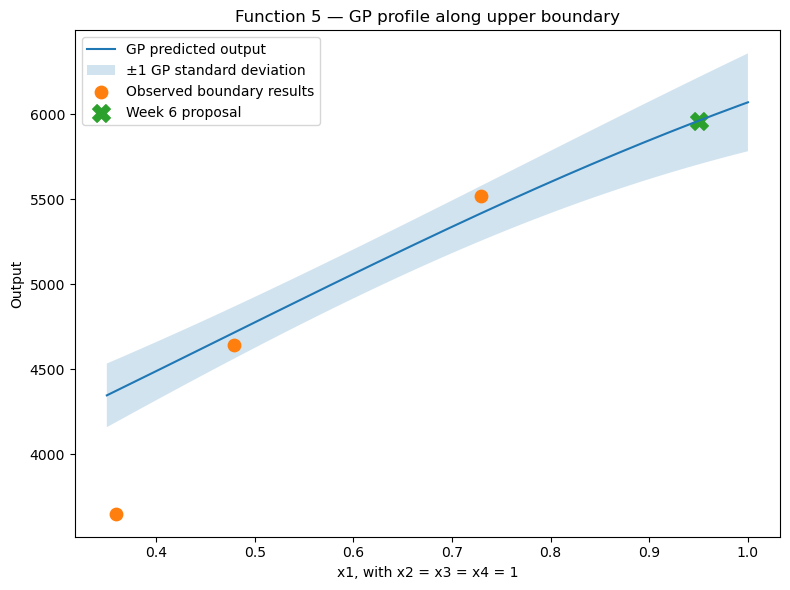

In [12]:
# ============================================================
# 13. FUNCTION 5 — x1 BOUNDARY PROFILE
# ============================================================

x1_grid = np.linspace(
    0.35,
    1.00,
    300
)

profile_points = np.column_stack([
    x1_grid,
    np.ones_like(x1_grid),
    np.ones_like(x1_grid),
    np.ones_like(x1_grid)
])

profile_mean_scaled, profile_std_scaled = gp.predict(
    profile_points,
    return_std=True
)

profile_mean = (
    profile_mean_scaled * Y_std
    + Y_mean
)

profile_std = (
    profile_std_scaled * Y_std
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    x1_grid,
    profile_mean,
    label="GP predicted output"
)

plt.fill_between(
    x1_grid,
    profile_mean - profile_std,
    profile_mean + profile_std,
    alpha=0.2,
    label="±1 GP standard deviation"
)

# Observed boundary points
plt.scatter(
    [0.359181, 0.479181, 0.729149],
    [
        3650.138639563766,
        4641.863904371854,
        5518.777035831257
    ],
    s=80,
    label="Observed boundary results"
)

plt.scatter(
    week6_query[0],
    filtered_mean[chosen_index],
    marker="X",
    s=160,
    label="Week 6 proposal"
)

plt.xlabel("x1, with x2 = x3 = x4 = 1")
plt.ylabel("Output")

plt.title(
    "Function 5 — GP profile along upper boundary"
)

plt.legend()
plt.tight_layout()
plt.show()